In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [13]:
df = pd.read_csv('../houseprice.csv')  
print(df.shape) 

(1460, 81)


In [14]:
# Выделяем признаки (X) и целевую переменную (y)
X = df.drop(['Id', 'SalePrice'], axis=1)  # удаляем Id и SalePrice из признаков
y = df['SalePrice']

# Разделение на обучающую и тестовую выборки (например, 80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape

((1168, 79), (292, 79))

In [15]:
# Первичный обзор данных
X_train.dtypes.value_counts()  
X_train.head(5)             
# Проверка пропущенных значений в обучающей выборке
missing = X_train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing value:\n", missing)

Missing value:
 PoolQC          1162
MiscFeature     1122
Alley           1094
Fence            935
MasVnrType       683
FireplaceQu      547
LotFrontage      217
GarageType        64
GarageYrBlt       64
GarageFinish      64
GarageQual        64
GarageCond        64
BsmtCond          28
BsmtFinType1      28
BsmtExposure      28
BsmtQual          28
BsmtFinType2      28
MasVnrArea         6
Electrical         1
dtype: int64


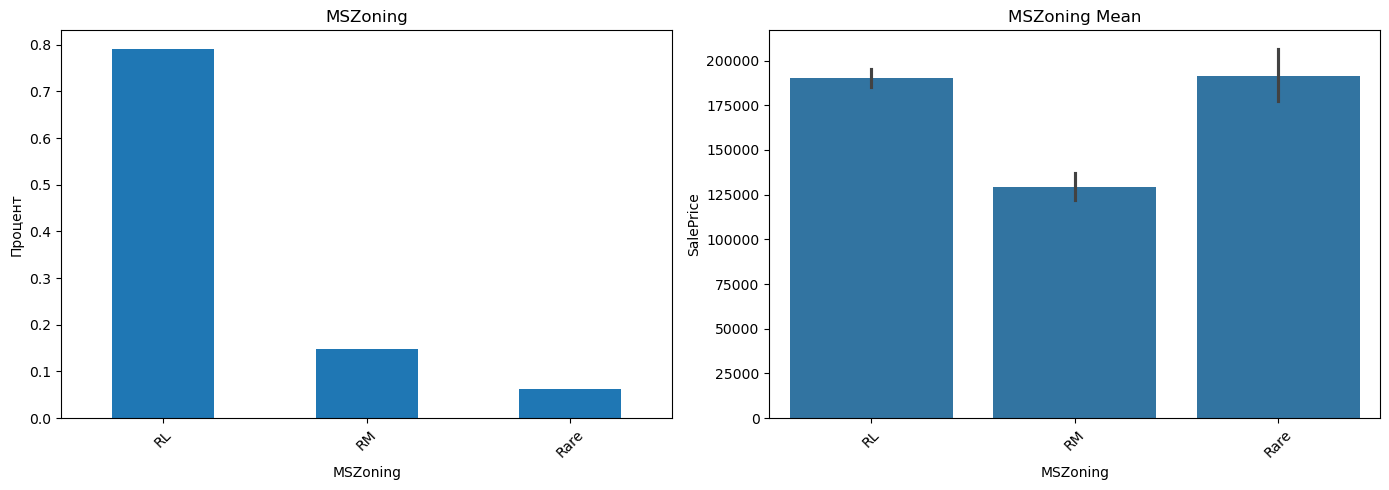

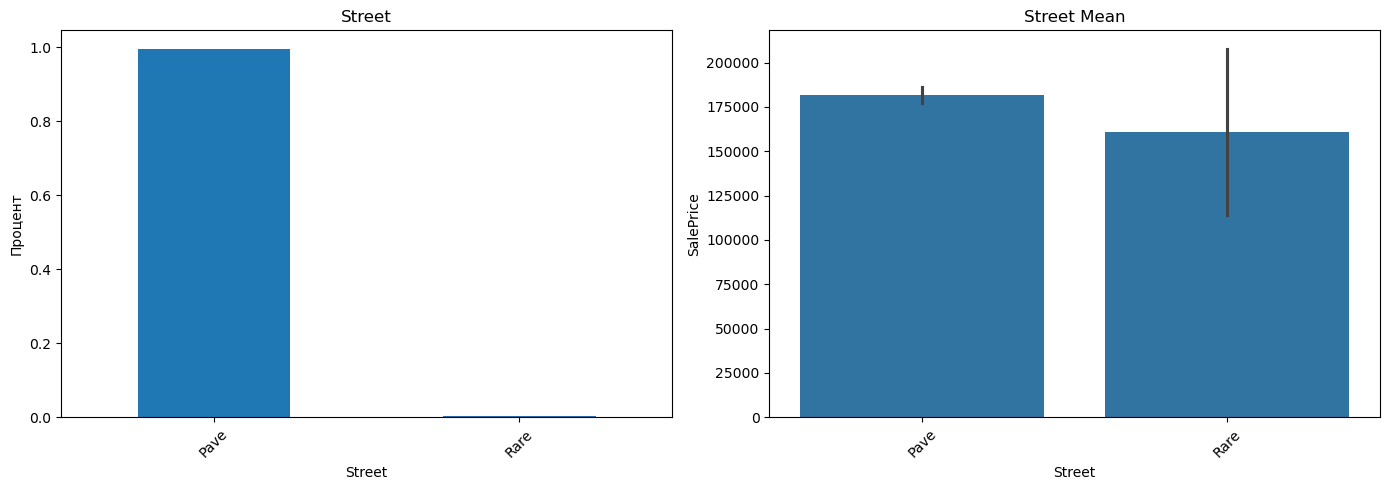

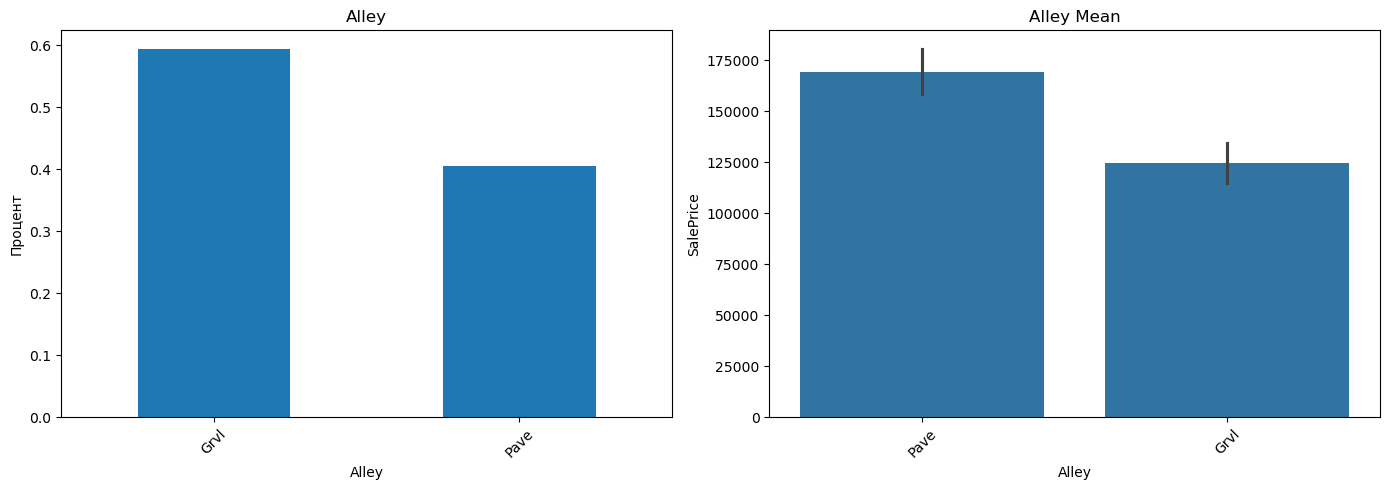

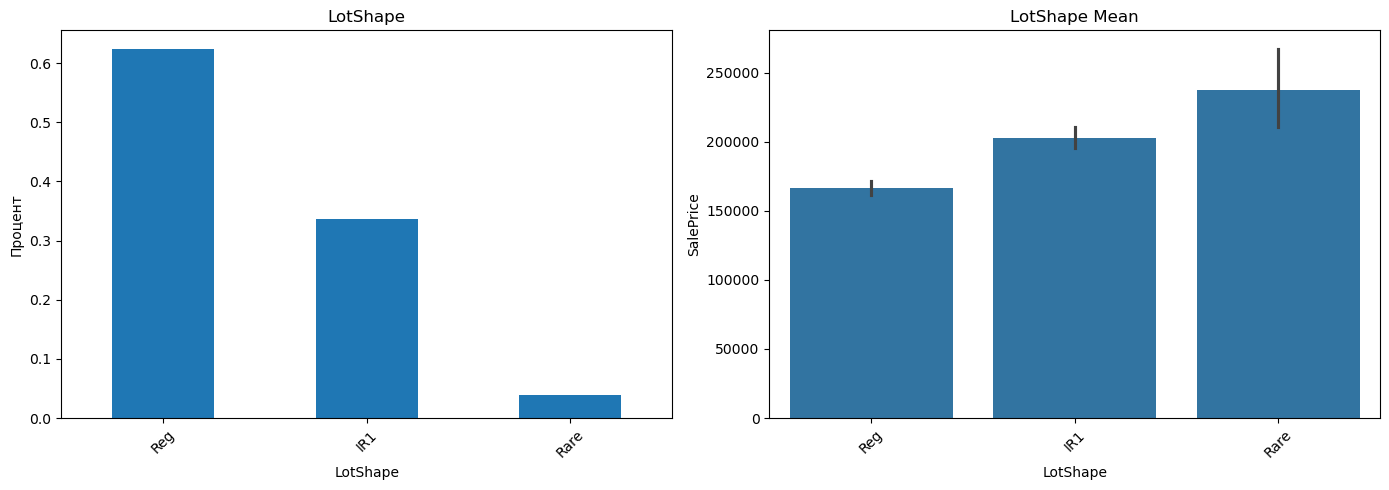

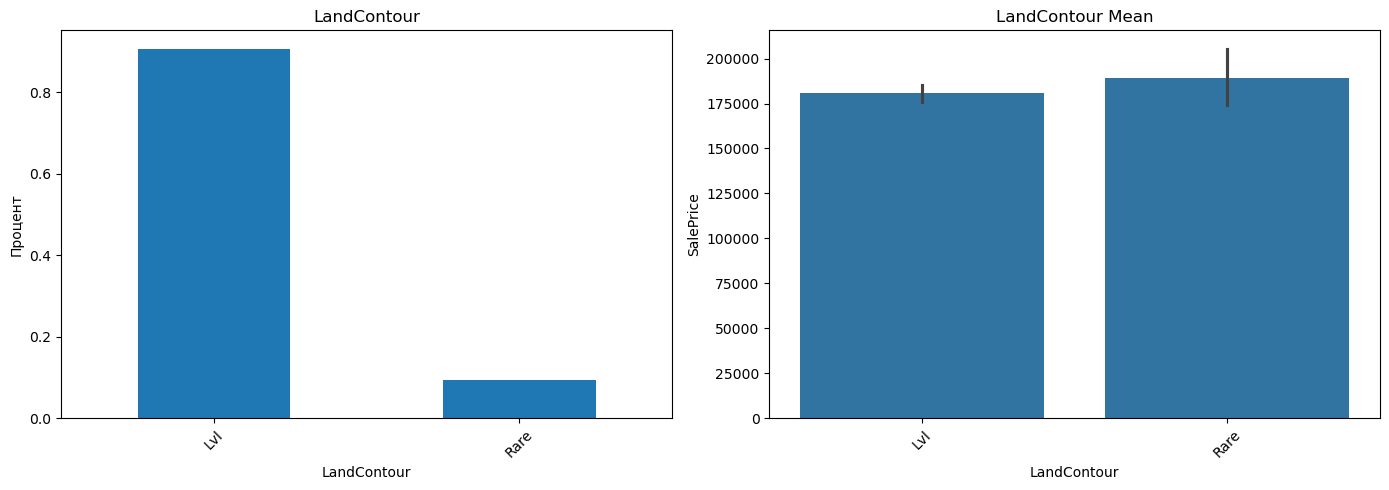

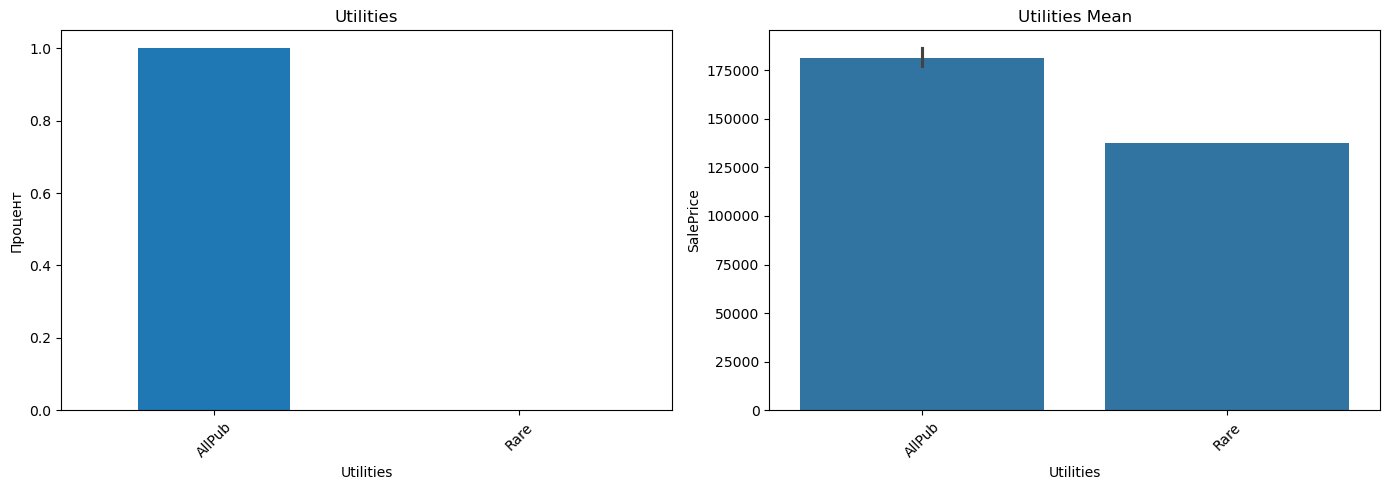

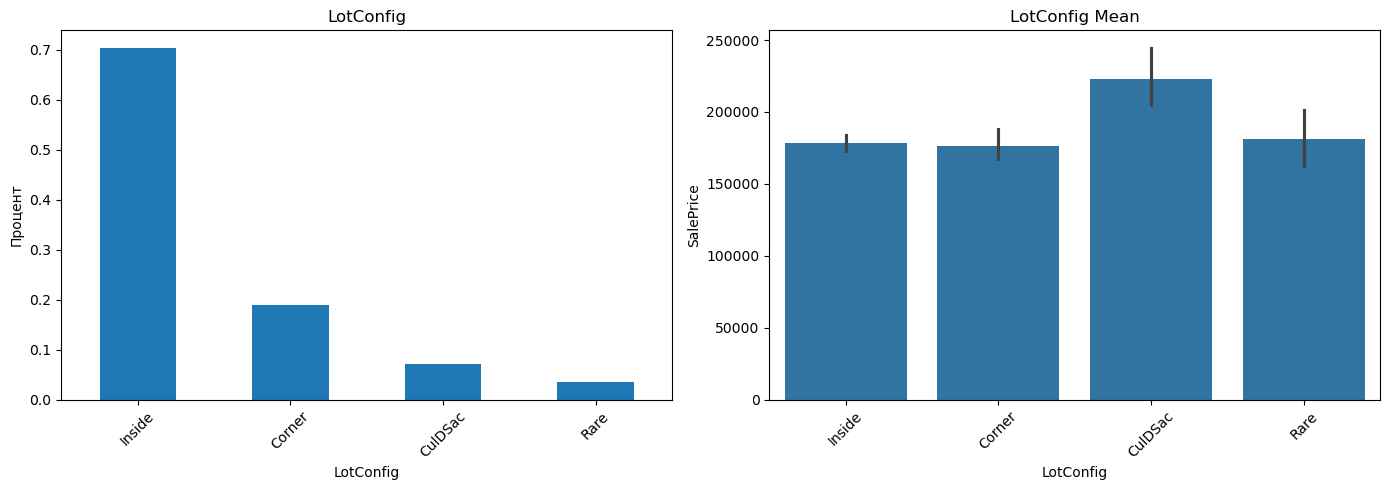

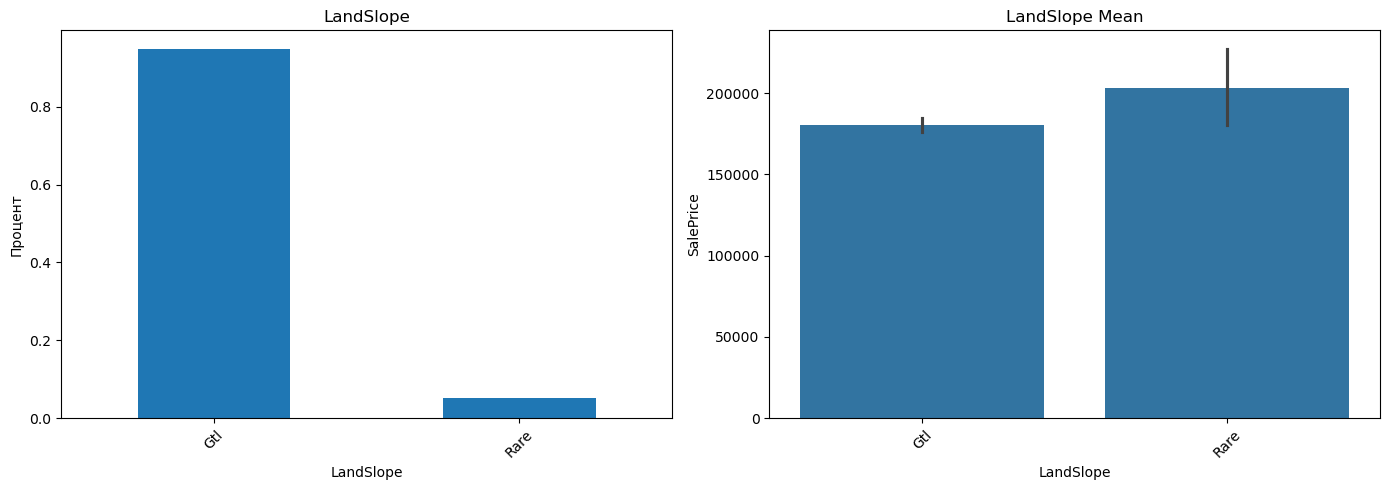

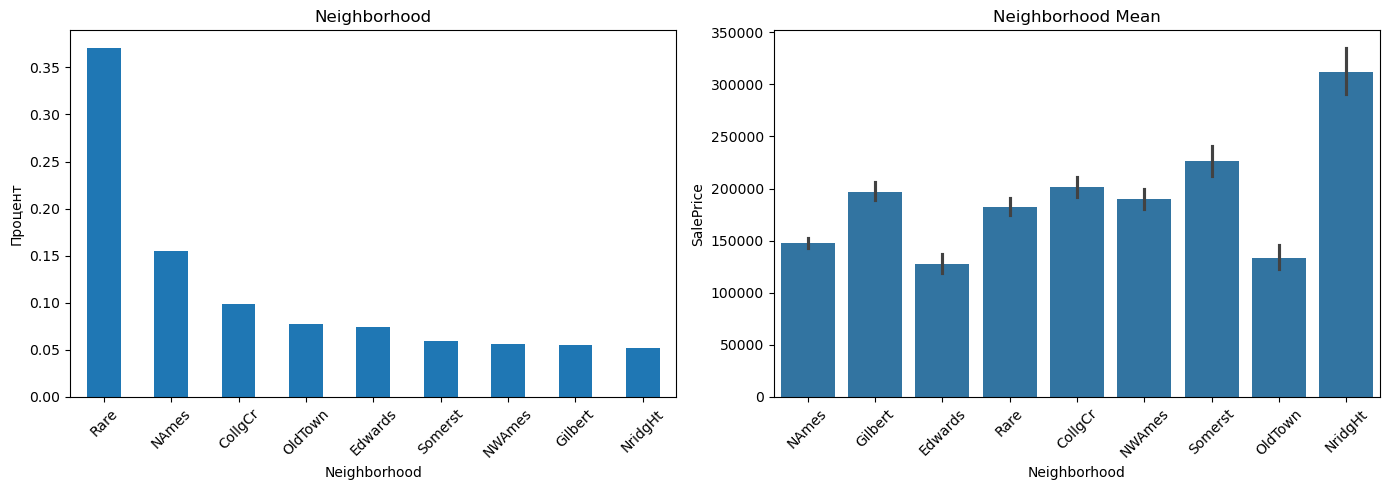

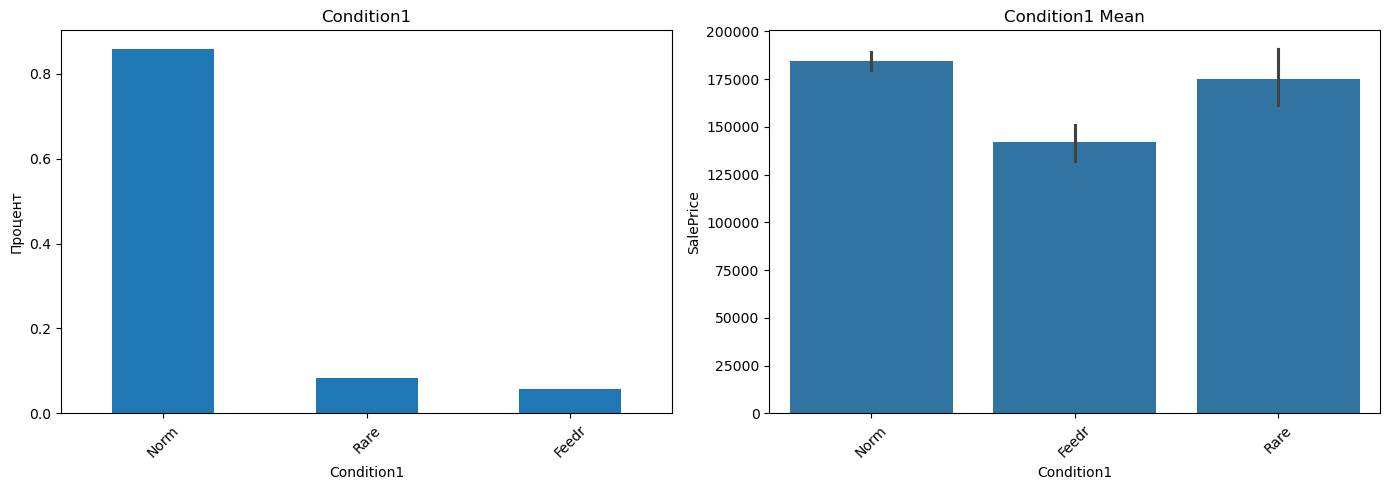

In [16]:
# Объединяем X_train и y_train для анализа
data = X_train.copy()
data['SalePrice'] = y_train

#Работа только с категориальными переменными
cat_columns = data.select_dtypes(include='object').columns

# Замена редких категорий на 'Rare'
for column in cat_columns:
    counts = data[column].value_counts(normalize=True)
    rare = counts[counts < 0.05].index
    data[column] = data[column].replace(rare, 'Rare')

# Выбор 10 категориальных признаков (с разными значениями)
top_columns = []
for column in cat_columns:
    if data[column].nunique() > 1:
        top_columns.append(column)
top_10 = top_columns[:10]

# Визуализация
for column in top_10:
    plt.figure(figsize=(14, 5))

    # Слева: доля каждой категории
    plt.subplot(1, 2, 1)
    data[column].value_counts(normalize=True).plot(kind='bar')
    plt.title(f'{column}')
    plt.ylabel('Процент')
    plt.xticks(rotation=45)

    # Справа: средняя цена по категориям
    plt.subplot(1, 2, 2)
    sns.barplot(x=column, y='SalePrice', data=data)
    plt.title(f'{column} Mean')
    plt.ylabel('SalePrice')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [17]:
# Заполнение пропусков для категориальных признаков "None" там, где NA означает отсутствие
cols_fill_none = [
    'Alley',        # нет доступа к аллее
    'MasVnrType',   # нет каменного облицовочного материала
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',  # нет подвала
    'FireplaceQu',  # нет камина
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',  # нет гаража
    'PoolQC',       # нет бассейна
    'Fence',        # нет забора
    'MiscFeature'   # нет прочих дополнительных строений
]
for col in cols_fill_none:
    X_train[col].fillna('None', inplace=True)
    X_test[col].fillna('None', inplace=True)

# Заполнение пропусков для числовых признаков нулями (если NA означает "нет объекта")
cols_fill_zero = ['MasVnrArea', 'GarageYrBlt'] 
# MasVnrArea: площадь каменного настила (0 если нет), GarageYrBlt: год постройки гаража (0 если гаража нет)
for col in cols_fill_zero:
    X_train[col].fillna(0, inplace=True)
    X_test[col].fillna(0, inplace=True)

# Числовой признак LotFrontage заполним медианой (в разрезе Neighborhood можно точнее, но используем общий упрощенно)
median_lotfrontage = X_train['LotFrontage'].median()
X_train['LotFrontage'].fillna(median_lotfrontage, inplace=True)
X_test['LotFrontage'].fillna(median_lotfrontage, inplace=True)

# Electrical: заполнение модой (самым частым значением)
most_freq_electrical = X_train['Electrical'].mode()[0]
X_train['Electrical'].fillna(most_freq_electrical, inplace=True)
X_test['Electrical'].fillna(most_freq_electrical, inplace=True)

# Удаление неинформативного признака Utilities (почти у всех 'AllPub')
if 'Utilities' in X_train.columns:
    X_train.drop('Utilities', axis=1, inplace=True)
    X_test.drop('Utilities', axis=1, inplace=True)

# Проверяем, осталось ли что-то пропущенное
print("Пропуски после заполнения:",
      X_train.isnull().sum().sum(), X_test.isnull().sum().sum())

Пропуски после заполнения: 0 0


C:\Temp\ipykernel_11940\2715037843.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train[col].fillna('None', inplace=True)
C:\Temp\ipykernel_11940\2715037843.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

In [18]:
# Определяем словари для порядковых категорий:
qual_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
# Применим к признакам качества отделки/материалов:
qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
             'HeatingQC', 'KitchenQual', 'FireplaceQu',
             'GarageQual', 'GarageCond', 'PoolQC']
for col in qual_cols:
    X_train[col] = X_train[col].map(qual_map)
    X_test[col]  = X_test[col].map(qual_map)

# Порядок для Basement Exposure (выход подвала): None=0, No=1, Mn=2, Av=3, Gd=4
exp_map = {'None':0, 'No':1, 'Mn':2, 'Av':3, 'Gd':4}
X_train['BsmtExposure'] = X_train['BsmtExposure'].map(exp_map)
X_test['BsmtExposure']  = X_test['BsmtExposure'].map(exp_map)

# Кодирование типа подвального помещения (финита) - 0 (None) до 6 (наилучшее)
fin_map = {'None':0, 'Unf':1, 'LwQ':2, 'Rec':3, 'BLQ':4, 'ALQ':5, 'GLQ':6}
X_train['BsmtFinType1'] = X_train['BsmtFinType1'].map(fin_map)
X_test['BsmtFinType1']  = X_test['BsmtFinType1'].map(fin_map)
X_train['BsmtFinType2'] = X_train['BsmtFinType2'].map(fin_map)
X_test['BsmtFinType2']  = X_test['BsmtFinType2'].map(fin_map)

# Отделка гаража: None=0, Unf=1, RFn=2, Fin=3
garage_finish_map = {'None':0, 'Unf':1, 'RFn':2, 'Fin':3}
X_train['GarageFinish'] = X_train['GarageFinish'].map(garage_finish_map)
X_test['GarageFinish']  = X_test['GarageFinish'].map(garage_finish_map)

# Подъездная дорога: N=0, P=1, Y=2 (N - нет, P - частично, Y - полностью вымощена)
paved_map = {'N':0, 'P':1, 'Y':2}
X_train['PavedDrive'] = X_train['PavedDrive'].map(paved_map)
X_test['PavedDrive']  = X_test['PavedDrive'].map(paved_map)

# (Можно добавить и другие порядковые признаки аналогично если требуется)

# 2) One-hot кодирование для остальных категориальных признаков
# pd.get_dummies автоматически закодирует все объектные столбцы, оставив числовые без изменений.
X_train_enc = pd.get_dummies(X_train)
X_test_enc = pd.get_dummies(X_test)

# Чтобы в тестовой выборке были такие же столбцы, как в обучающей:
for col in X_train_enc.columns:
    if col not in X_test_enc.columns:
        X_test_enc[col] = 0  # добавляем недостающий столбец в test с 0
for col in X_test_enc.columns:
    if col not in X_train_enc.columns:
        X_train_enc[col] = 0
# Теперь выравниваем порядок столбцов
X_test_enc = X_test_enc[X_train_enc.columns]
X_train_enc.shape, X_test_enc.shape

((1168, 239), (292, 239))

In [19]:
# Логарифмируем числовые признаки с сильным перекосом распределения
skewed_features = ['LotFrontage','LotArea','MasVnrArea','BsmtFinSF1','BsmtFinSF2',
                   'BsmtUnfSF','TotalBsmtSF','1stFlrSF','2ndFlrSF','LowQualFinSF',
                   'GrLivArea','GarageArea','WoodDeckSF','OpenPorchSF',
                   'EnclosedPorch','3SsnPorch','ScreenPorch','PoolArea','MiscVal']
for col in skewed_features:
    if col in X_train_enc.columns:
        X_train_enc[col] = np.log1p(X_train_enc[col])
        X_test_enc[col] = np.log1p(X_test_enc[col])

# Также логарифмируем целевую переменную SalePrice
y_train_log = np.log1p(y_train)
# (y_test пока не преобразуем, сохраним для обратного преобразования при оценке)

In [20]:
# Удаляем признаки-дубликаты с высокой корреляцией
cols_to_drop = ['GarageArea', '1stFlrSF', 'TotRmsAbvGrd', 'GarageYrBlt']
X_train_enc.drop(cols_to_drop, axis=1, inplace=True)
X_test_enc.drop(cols_to_drop, axis=1, inplace=True)
X_train_enc.shape, X_test_enc.shape


((1168, 235), (292, 235))

In [21]:
# Удаляем признаки-дубликаты с высокой корреляцией
cols_to_drop = ['GarageArea', '1stFlrSF', 'TotRmsAbvGrd', 'GarageYrBlt']
cols_in_train = [col for col in cols_to_drop if col in X_train_enc.columns]
cols_in_test = [col for col in cols_to_drop if col in X_test_enc.columns]

X_train_enc.drop(cols_in_train, axis=1, inplace=True)
X_test_enc.drop(cols_in_test, axis=1, inplace=True)

X_train_enc.shape, X_test_enc.shape

((1168, 235), (292, 235))

In [22]:
scaler = StandardScaler()
# Фиттинг на обучающих данных
X_train_scaled = scaler.fit_transform(X_train_enc)
# Применение масштаба к тестовым данным
X_test_scaled = scaler.transform(X_test_enc)

In [23]:
# Инициализируем модели с базовыми параметрами
linreg = LinearRegression()
ridge = Ridge(alpha=10)  # пример: Ridge с некоторым коэффициентом регуляризации
rf = RandomForestRegressor(n_estimators=100, random_state=42)
gbr = GradientBoostingRegressor(random_state=42)

# Обучаем модели на обучающих данных (X_train_scaled, y_train_log)
linreg.fit(X_train_scaled, y_train_log)
ridge.fit(X_train_scaled, y_train_log)
rf.fit(X_train_scaled, y_train_log)
gbr.fit(X_train_scaled, y_train_log)

GradientBoostingRegressor(random_state=42)

In [24]:
# Функция для вычисления метрик по предсказаниям логарифма цены
def eval_model(model, name):
    # Предсказываем логарифм цены
    y_pred_log = model.predict(X_test_scaled)
    # Обратное преобразование к исходной цене
    y_pred = np.expm1(y_pred_log)
    # Метрики
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{name}: R^2 = {r2:.3f}, RMSE = {rmse:.0f}")

# Вычислим метрики для каждой модели
eval_model(linreg, "Linear Regression")
eval_model(ridge, "Ridge Regression")
eval_model(rf, "Random Forest")
eval_model(gbr, "Gradient Boosting")


C:\Temp\ipykernel_11940\208131053.py:6: RuntimeWarning: overflow encountered in expm1
  y_pred = np.expm1(y_pred_log)


ValueError: Input contains infinity or a value too large for dtype('float64').